In [1]:
### Hayden Gallo
### 11/5/25
### Bucci Lab

### The goal of this notebook is to be able to implement running a stability analysis on MDSINE2 inference to then inform regime switching for FBA backend.

from typing import *
from pathlib import Path
import itertools
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
import scipy.stats
from statsmodels.stats.multitest import fdrcorrection
import os

import mdsine2 as md2
from mdsine2.names import STRNAMES

from tqdm import tqdm

# Make font editable in AI
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

[DEBUG] Using default logger (stdout, stderr).


In [76]:
### here define the jacobain function


def linstability_get_steadystates_and_eigenvalues(end_profile, start_profile, Beta, alpha):
    """
    Python/Numpy port of Vanni Bucci's MATLAB function:
    linstability_get_steadystates_and_eigenvalues.m
 
    Parameters
    ----------
    end_profile : array_like of bool/int (shape: n,)
        Indicator of taxa present in the final (steady) profile.
    start_profile : array_like of bool/int (shape: n,)
        Indicator of taxa present in the starting profile.
    Beta : array_like (shape: n, n)
        Interaction matrix (gLV A or Beta).
    alpha : array_like (shape: n,)
        Intrinsic growth vector.
 
    Returns
    -------
    eigvals : np.ndarray (shape: m,) or np.ndarray([np.nan])
        Eigenvalues of the Jacobian at the steady state restricted to the
        start_profile subspace. If the Jacobian/eigendecomposition fails,
        returns array([np.nan]).
    fss : np.ndarray (shape: n,)
        Full steady-state vector (zeros where end_profile==0), with
        fss[end_profile] = - Beta_2^{-1} * alpha_2.
    alpha_1 : np.ndarray (shape: m,)
        alpha restricted to start_profile.
    Beta_1 : np.ndarray (shape: m, m)
        Beta restricted to start_profile x start_profile.
 
    Notes
    -----
    - Uses a linear solve instead of explicit matrix inversion.
    - Replicates MATLAB’s indexing and Jacobian construction.
    """
    # Ensure numpy arrays and boolean masks
    end_profile   = np.asarray(end_profile).astype(bool)
    start_profile = np.asarray(start_profile).astype(bool)
    Beta  = np.asarray(Beta, dtype=float)
    alpha = np.asarray(alpha, dtype=float)
 
    # Reduced matrices/vectors on start_profile
    Beta_1  = Beta[np.ix_(start_profile, start_profile)]
    alpha_1 = alpha[start_profile]
 
    # Steady state on the intersection of start & end
    in_both = start_profile & end_profile
    Beta_2  = Beta[np.ix_(in_both, in_both)]
    alpha_2 = alpha[in_both]
 
    # fss initialized to zeros, then fill only where end_profile is True
    fss = np.zeros_like(alpha)
    try:
        # Solve Beta_2 * x = -alpha_2  →  x = -solve(Beta_2, alpha_2)
        if Beta_2.size > 0:
            fss[in_both] = -np.linalg.solve(Beta_2, alpha_2)
    except np.linalg.LinAlgError:
        # Singular or ill-conditioned; leave fss as is (zeros), continue
        pass
 
    # fss restricted to start_profile
    fss2 = fss[start_profile]
 
    # Build Jacobian on the start_profile subspace (matches MATLAB loops)
    m = Beta_1.shape[0]
    Jacobian_matrix = np.zeros((m, m), dtype=float)
 
    # Precompute row-wise sums Beta_1[i, :] * fss2 (dot product)
    row_dot = Beta_1 @ fss2  # shape (m,)
 
    for im in range(m):
        for jm in range(m):
            if im == jm:
                # alpha_1(i) + Beta_1(i,i)*fss2(i) + sum_k Beta_1(i,k)*fss2(k)
                Jacobian_matrix[im, jm] = alpha_1[im] + Beta_1[im, im] * fss2[im] + row_dot[im]
            else:
                # Beta_1(i,j) * fss2(i)
                Jacobian_matrix[im, jm] = Beta_1[im, jm] * fss2[im]
 
    # Eigenvalues of Jacobian
    try:
        eigvals = np.linalg.eigvals(Jacobian_matrix)
    except np.linalg.LinAlgError:
        eigvals = np.array([np.nan])
 
    return eigvals, fss, alpha_1, Beta_1

    

In [2]:
print(os.getcwd())

/Users/haydengallo/UMass_Dropbox/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA


In [40]:
data_dir = Path('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/merged_studies_fixed_cluster_100_its_daily')


In [41]:
### load the mcmc pkl

pkl_path = data_dir / "mcmc.pkl"


mcmc = md2.BaseMCMC.load(str(pkl_path))

mcmc


In [42]:
interactions = mcmc.graph[STRNAMES.INTERACTIONS_OBJ].get_trace_from_disk(section='posterior')



interactions[np.isnan(interactions)] = 0

self_interactions = mcmc.graph[STRNAMES.SELF_INTERACTION_VALUE].get_trace_from_disk(section='posterior')
self_interactions = -np.absolute(self_interactions)

for i in range(self_interactions.shape[1]):
    interactions[:, i, i] = self_interactions[:, i]

interactions

array([[[-1.67015551e-10,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -2.10162628e-09,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00, -5.64368088e-11, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -4.27707077e-09,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -1.27748436e-09,  0.00000000e+00, ...,
          0.00000000e+00, -4.41554842e-10, -1.36963351e-09],
        [ 0.00000000e+00,  0.00000000e+00, -1.07870961e-10, ...,
          0.00000000e+00,  5.68711967e-10, -1.37526965e-09]],

       [[-2.26720175e-10,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -2.05314753e-09,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e

In [49]:
growths = mcmc.graph[STRNAMES.GROWTH_VALUE].get_trace_from_disk(section='posterior')
growths.shape

(50, 15)

In [61]:
abun_df = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/merged_studies_fixed_cluster_100_its_daily/posterior/filtering/Subject_1999/mean.tsv', sep='\t', index_col=0)
abun_df.head()

,-3.0,-2.0,-1.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
14ac4eaad5b4e2ff3c071832e0fd4229,3.226346e+08,9.564387e+07,2.066436e+07,3.409495e+08,1.076307e+09,7.783674e+08,2.653361e+06,3.769042e+05,4.381579e+05,4.924691e+06,1.837035e+06,2.875288e+07,1.039087e+08,3.586833e+08,7.507241e+09,8.139861e+08,3.551252e+08,2.181531e+09
18673193aa6bf30c6a1e71ac504e04df,3.161633e+02,2.168678e+00,1.189364e+02,5.287437e+04,1.057505e+06,8.937730e+06,5.141713e+04,4.410584e+04,7.711218e+02,8.380812e+01,2.870997e+01,3.149824e+01,7.238356e+01,1.243200e+01,7.389658e+02,5.868093e+01,4.975739e+01,8.018804e+01
320dfd16200daaf2b0503975d4e68fd5,1.177060e+08,3.866439e+07,5.727555e+07,1.520551e+09,1.265098e+10,3.410874e+09,1.936534e+07,6.324992e+06,2.471890e+06,2.460648e+08,2.330371e+08,5.748279e+08,3.383271e+08,5.476187e+08,1.444933e+09,2.542753e+09,3.301334e+09,4.780124e+09
36173253c63ad49abc12361a0b3304eb,8.227411e+09,1.945493e+09,1.928614e+08,3.519449e+07,1.395058e+07,1.439693e+08,4.912561e+05,4.774410e+05,6.602944e+06,2.161769e+07,1.280869e+08,1.392833e+08,4.713265e+07,4.120786e+08,2.702924e+09,1.009040e+09,8.319285e+08,7.540312e+08
391821255f31ef94686927f4fba6fbc3,5.080054e+09,7.797956e+07,9.846300e+06,2.121102e+06,1.697578e+06,2.672772e+04,2.067641e+04,1.888298e+02,1.950287e+02,2.261647e+05,3.494055e+07,7.958690e+08,6.414907e+08,6.771030e+08,1.788814e+09,1.030973e+10,5.835742e+09,1.403494e+10


In [62]:
abun_array = np.array(abun_df).T

In [63]:
abun_array.shape

(18, 15)

In [46]:
interactions.shape

(50, 15, 15)

In [39]:
np.diag(β)

array([-9.35318254e-10, -3.77024860e-11, -2.85278404e-08, -9.56714612e-10,
       -1.38590453e-09, -1.70072116e-08, -6.64338178e-09, -2.23115321e-10,
       -2.71115404e-08])

In [81]:
import numpy as np
from numpy.linalg import eig, inv

# Example data
T = 18     # time points
L = 15        # species
K = 50      # MCMC samples

# Simulated abundances (could be from your gLV simulation)
#X = np.abs(np.random.randn(T, L))  # shape (T, L)

# Simulated MCMC samples for alpha and beta
#alpha_samples = np.random.randn(K, L) * 0.1
#beta_samples = np.random.randn(K, L, L) * 0.05
#for k in range(K):
#    np.fill_diagonal(beta_samples[k], -0.1 + np.random.randn(L) * 0.1)  # ensure self-limiting

# Threshold to determine presence/absence
epsilon = 1e6

# Storage for stability probabilities
P_stable = np.zeros(T)

for t in range(T):
    active = np.where(abun_array[t, :] > epsilon)[0]
    if len(active) == 0:
        P_stable[t] = np.nan
        continue

    stable_count = 0

    for k in range(K):
        α = growths[k, active]
        β = interactions[k][np.ix_(active, active)]

        try:
            # Compute steady state for this subcommunity
            x_star = -inv(β) @ α

            # Skip invalid (negative) steady states
            if np.any(x_star <= 0):
                continue

            # Compute Jacobian at steady state
            J = np.diag(x_star) @ β

            # Check eigenvalues
            eigvals = eig(J)[0]
            if np.all(np.real(eigvals) < 0):
                stable_count += 1
                print('yes')
        except np.linalg.LinAlgError:
            # Skip if β is singular
            continue

    P_stable[t] = stable_count / K

print("Stability probability at each time point:")
print(P_stable)


yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
Stability probability at each time point:
[0.   0.   0.   0.   0.   0.   0.   0.08 0.12 0.   0.   0.   0.   0.
 0.   0.   0.   0.04]


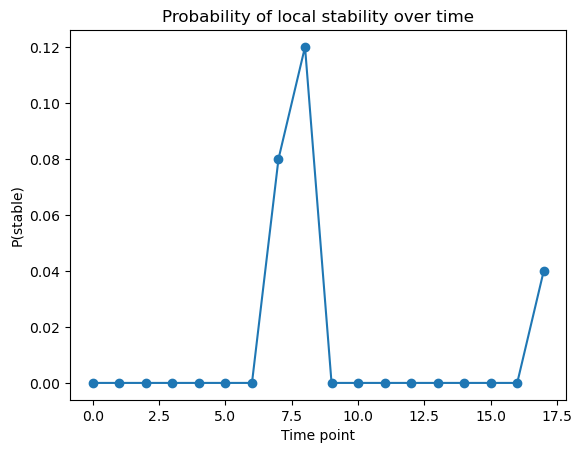

In [82]:
import matplotlib.pyplot as plt

plt.plot(range(T), P_stable, marker='o')
plt.xlabel('Time point')
plt.ylabel('P(stable)')
plt.title('Probability of local stability over time')
plt.show()


In [83]:
n_species = 15
n_timepoints = 18
n_samples = 50


In [84]:
abun_df

,-3.0,-2.0,-1.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
14ac4eaad5b4e2ff3c071832e0fd4229,3.226346e+08,9.564387e+07,2.066436e+07,3.409495e+08,1.076307e+09,7.783674e+08,2.653361e+06,3.769042e+05,4.381579e+05,4.924691e+06,1.837035e+06,2.875288e+07,1.039087e+08,3.586833e+08,7.507241e+09,8.139861e+08,3.551252e+08,2.181531e+09
18673193aa6bf30c6a1e71ac504e04df,3.161633e+02,2.168678e+00,1.189364e+02,5.287437e+04,1.057505e+06,8.937730e+06,5.141713e+04,4.410584e+04,7.711218e+02,8.380812e+01,2.870997e+01,3.149824e+01,7.238356e+01,1.243200e+01,7.389658e+02,5.868093e+01,4.975739e+01,8.018804e+01
320dfd16200daaf2b0503975d4e68fd5,1.177060e+08,3.866439e+07,5.727555e+07,1.520551e+09,1.265098e+10,3.410874e+09,1.936534e+07,6.324992e+06,2.471890e+06,2.460648e+08,2.330371e+08,5.748279e+08,3.383271e+08,5.476187e+08,1.444933e+09,2.542753e+09,3.301334e+09,4.780124e+09
36173253c63ad49abc12361a0b3304eb,8.227411e+09,1.945493e+09,1.928614e+08,3.519449e+07,1.395058e+07,1.439693e+08,4.912561e+05,4.774410e+05,6.602944e+06,2.161769e+07,1.280869e+08,1.392833e+08,4.713265e+07,4.120786e+08,2.702924e+09,1.009040e+09,8.319285e+08,7.540312e+08
391821255f31ef94686927f4fba6fbc3,5.080054e+09,7.797956e+07,9.846300e+06,2.121102e+06,1.697578e+06,2.672772e+04,2.067641e+04,1.888298e+02,1.950287e+02,2.261647e+05,3.494055e+07,7.958690e+08,6.414907e+08,6.771030e+08,1.788814e+09,1.030973e+10,5.835742e+09,1.403494e+10
3936cc515320e9f29d81ffeaa92718e8,4.948263e+08,7.237269e+08,2.817939e+06,5.427415e+04,6.121149e+05,9.752551e+03,1.009822e+02,1.340576e+02,4.937083e+03,1.224397e+07,2.870356e+06,2.125103e+08,6.098904e+08,1.039249e+09,2.064623e+09,1.886681e+09,2.203661e+08,2.084314e+09
3e741fc097143bb6782af5233cb7af98,1.315252e+10,4.836316e+09,2.306287e+07,3.440041e+06,3.305861e+05,5.630443e+04,8.450260e+02,4.931099e+02,8.954091e+03,3.023452e+06,2.361215e+07,7.031549e+06,1.618887e+07,4.770913e+08,1.919505e+09,2.427754e+09,2.003616e+09,6.482163e+09
4cc9a4b9aaa3ee9a5c14cc27551a6844,1.836151e+04,1.745561e+04,5.630980e+02,2.507815e+02,1.712864e+03,1.308949e+05,1.109857e+07,1.325124e+08,1.225066e+10,7.391492e+08,1.522698e+10,1.875674e+08,6.637058e+08,4.654775e+07,1.595557e+08,2.897481e+07,4.719502e+07,2.735559e+05
795b6ba45f502a00b24b212278991c63,3.731284e+09,6.872149e+10,1.876710e+10,1.262511e+09,1.942948e+08,5.135917e+07,7.649496e+05,3.231632e+06,1.731141e+06,3.856272e+07,6.643749e+07,6.253049e+07,3.762864e+08,3.742832e+09,9.843899e+09,1.313724e+09,6.879528e+07,1.433408e+08
7ca7ca8214441730c2437d1f53390cdb,9.280918e+09,1.547614e+10,2.024839e+09,2.096090e+09,4.923861e+09,1.562412e+09,9.561603e+09,4.112701e+08,2.937430e+09,1.169507e+09,8.668476e+09,4.156722e+09,7.351624e+09,5.489355e+09,2.368309e+10,1.213129e+09,4.912176e+09,1.587244e+10


In [85]:
abun_df_filt = abun_df.copy()

abun_df_filt[abun_df_filt < 1e5] = 0
abun_df_filt[abun_df_filt > 1e5] = 1
#

In [86]:
abun_array_filt = np.array(abun_df_filt).T
abun_array_filt

array([[1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0.],
       [1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0.],
       [1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1.],
       [1., 0., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1.],
       [1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1.],
       [1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1.],
       [1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1.],
       [1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0.],
       [1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0.],
       [1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0.],
       [1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0.],
       [1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0.],
       [1., 0., 1., 1., 1., 1., 1.

In [87]:
import numpy as np

def linstability_get_steadystates_and_eigenvalues(end_profile, start_profile, Beta, alpha):
    end_profile   = np.asarray(end_profile).astype(bool)
    start_profile = np.asarray(start_profile).astype(bool)
    Beta  = np.asarray(Beta, dtype=float)
    alpha = np.asarray(alpha, dtype=float)

    Beta_1  = Beta[np.ix_(start_profile, start_profile)]
    alpha_1 = alpha[start_profile]
    in_both = start_profile & end_profile
    Beta_2  = Beta[np.ix_(in_both, in_both)]
    alpha_2 = alpha[in_both]

    fss = np.zeros_like(alpha)
    try:
        if Beta_2.size > 0:
            fss[in_both] = -np.linalg.solve(Beta_2, alpha_2)
    except np.linalg.LinAlgError:
        pass

    fss2 = fss[start_profile]
    m = Beta_1.shape[0]
    Jacobian_matrix = np.zeros((m, m), dtype=float)
    row_dot = Beta_1 @ fss2
    for im in range(m):
        for jm in range(m):
            if im == jm:
                Jacobian_matrix[im, jm] = alpha_1[im] + Beta_1[im, im]*fss2[im] + row_dot[im]
            else:
                Jacobian_matrix[im, jm] = Beta_1[im, jm]*fss2[im]

    try:
        eigvals = np.linalg.eigvals(Jacobian_matrix)
    except np.linalg.LinAlgError:
        eigvals = np.array([np.nan])
    return eigvals


In [88]:
stability_prob = np.zeros(n_timepoints)

for t in range(n_timepoints):
    start_profile = abun_array_filt[t]
    end_profile = abun_array_filt[t]  # assume same for simplicity
    
    stable_count = 0
    for i in range(n_samples):
        print(i)
        alpha = growths[i]
        Beta = interactions[i]
        eigvals = linstability_get_steadystates_and_eigenvalues(end_profile, start_profile, Beta, alpha)
        if np.all(np.real(eigvals) < 0):
            stable_count += 1
    
    stability_prob[t] = stable_count / n_samples

print("P_stable(t):", np.round(stability_prob, 3))


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
0
1
2
3
4
5
6
7
8
9
